In [1]:
# Time Series Forecasting

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use('seaborn-v0_8-colorblind')

In [3]:
# Import time series data: Airline passenger traffic

data = pd.read_csv(
    'https://raw.githubusercontent.com/ingledarshan/upGrad_Darshan/main/airline-passenger-traffic.csv',
    header=None)
data.head()

,0,1
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [4]:
data.columns = ['Month','Passengers']
data.head()

,Month,Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [5]:
data.tail()

,Month,Passengers
139,1960-08,606.0
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [6]:
data.shape
# Jan 1949 to Dec 1960: 12 years of data, 144 months, 144 data points

# Dataset columns description:
# - Month: Month of the year (Jan, Feb, Mar, etc.)
# - Passengers: Number of airline passengers in that month

(144, 2)

In [7]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Month       144 non-null    object 
 1   Passengers  140 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.4+ KB


In [8]:
data['year']=data['Month'].str.split('-').str[0]
data.year

0      1949
1      1949
2      1949
3      1949
4      1949
       ... 
139    1960
140    1960
141    1960
142    1960
143    1960
Name: year, Length: 144, dtype: object

In [9]:
# Lets convert the Month column to datetime format and set it as index
data['Month'] = pd.to_datetime(data['Month'], format='%Y-%m')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Month       144 non-null    datetime64[ns]
 1   Passengers  140 non-null    float64       
 2   year        144 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 3.5+ KB


In [10]:
data.head()

,Month,Passengers,year
0,1949-01-01,112.0,1949
1,1949-02-01,118.0,1949
2,1949-03-01,132.0,1949
3,1949-04-01,129.0,1949
4,1949-05-01,121.0,1949


In [11]:
###data = data.set_index('Month')

###data.head(12)

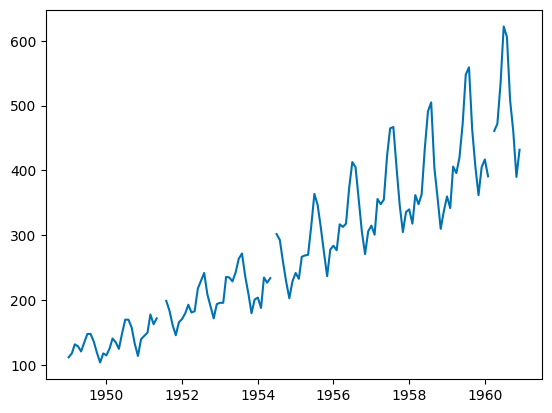

In [12]:
plt.plot(data['Month'],data['Passengers'])
plt.show()

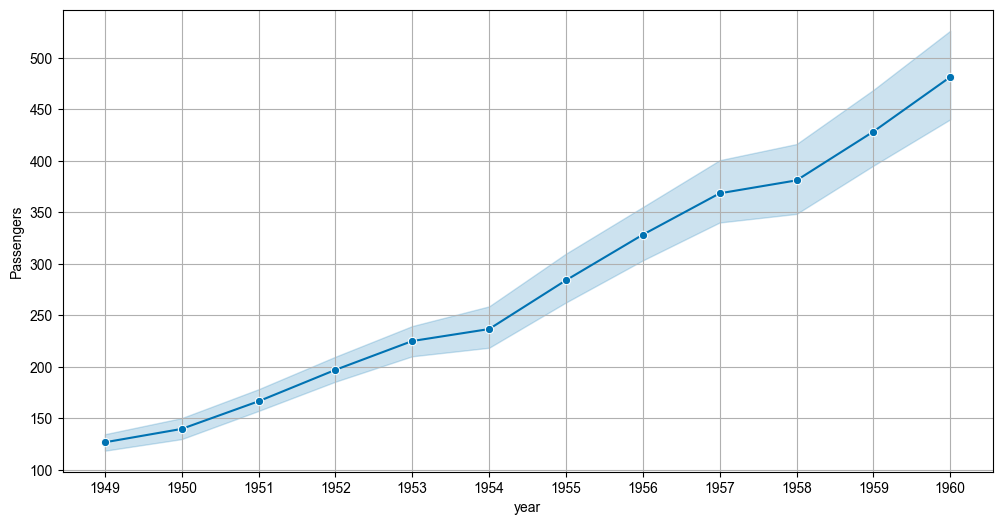

In [13]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x=data['year'],
    y=data['Passengers'],
    marker='o'
)
sns.set_style("whitegrid")
plt.grid(True)
plt.show()

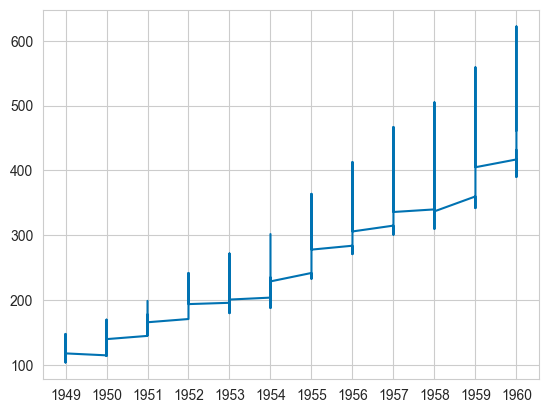

<Figure size 1000x300 with 0 Axes>

In [14]:
plt.plot(data.year,data.Passengers)

plt.figure(figsize=(10,3))
plt.show()

In [15]:
data.drop(columns=['year'],inplace=True)

In [16]:
data.columns

Index(['Month', 'Passengers'], dtype='object')

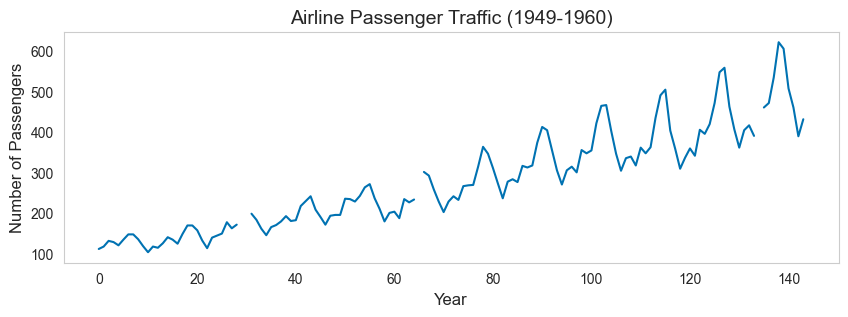

In [17]:
# Time series analysis
# Plot time series data

plt.figure(figsize=(10,3))
plt.plot(data.index, data['Passengers'])
plt.title('Airline Passenger Traffic (1949-1960)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.show()

In [18]:
# Lets inspect the missing values in the dataset
data.isnull().sum()

Month         0
Passengers    4
dtype: int64

## Missing value treatment

There are several ways to fill the missing values in the time series data:

>__1. Forward  Fill(or last observation carried forward -LOCF):__ here we replace the missing values with the last observed value. Use this when the series data has a stable trend or when the missing values occurs sporadically.

>__2. Backward fill(or next observation carried backward -NOCB):__ replace missing, missing values with the observed value. Use this when the time series data has a stable trend or when missing values occur, sporadically in the beginning of the time series.

>__3. Mean Inputation:__ replace the missing values with the mean of the observed values. Use this when the missing values are randomly distributed and do not affect the overall trend or seasonality of the time series.

>__4. Interpolation:__ estimate missing values based on the values before, and after the missing data points. Linear interpolation assumes a straight line between the neighbouring points., while spline interpolation Fit a smooth curve through the neighbouring points. Use this when the time series data has a smooth trend or when missing values occur within a relatively short span.

>__5. Seasonal imputation:__ replace missing values with the values from the same season in previous years. Use this when the time series data exhibits, seasonal patterns and missing values occur during specific seasons.

>__6. Machine learning methods:__ utilise machine learning algorithm, such as K, nearest neighbours or regression models to predict the missing values based on the observed data. Use this when missing values are complex and cannot be easily filled using the simple methods, and when there are enough observed data points to train the model effectively.

__The choice of method depends on the nature of the missing data, the underlying patterns in the time series, and the specific requirements of the analysis or forecasting task. Therefore, it is important to assess the impact of each method on the overall accuracy and reliability of the time series analysis.__

In [19]:
data.Passengers.mean()

np.float64(280.73571428571427)

In [20]:
data.head(3)

,Month,Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0


In [21]:
data['Passengers_Mean_Imputation'] = data['Passengers']
data['Passengers_Mean_Imputation'] = (
    data['Passengers_Mean_Imputation']
    .fillna(data['Passengers'].mean())
)


In [22]:
data = data.assign(Passengers_Mean_Imputation=data.Passengers.fillna(data.Passengers.mean()))
data.head()

,Month,Passengers,Passengers_Mean_Imputation
0,1949-01-01,112.0,112.0
1,1949-02-01,118.0,118.0
2,1949-03-01,132.0,132.0
3,1949-04-01,129.0,129.0
4,1949-05-01,121.0,121.0


In [23]:
# Lets check for missing values
data.isnull().sum()

Month                         0
Passengers                    4
Passengers_Mean_Imputation    0
dtype: int64

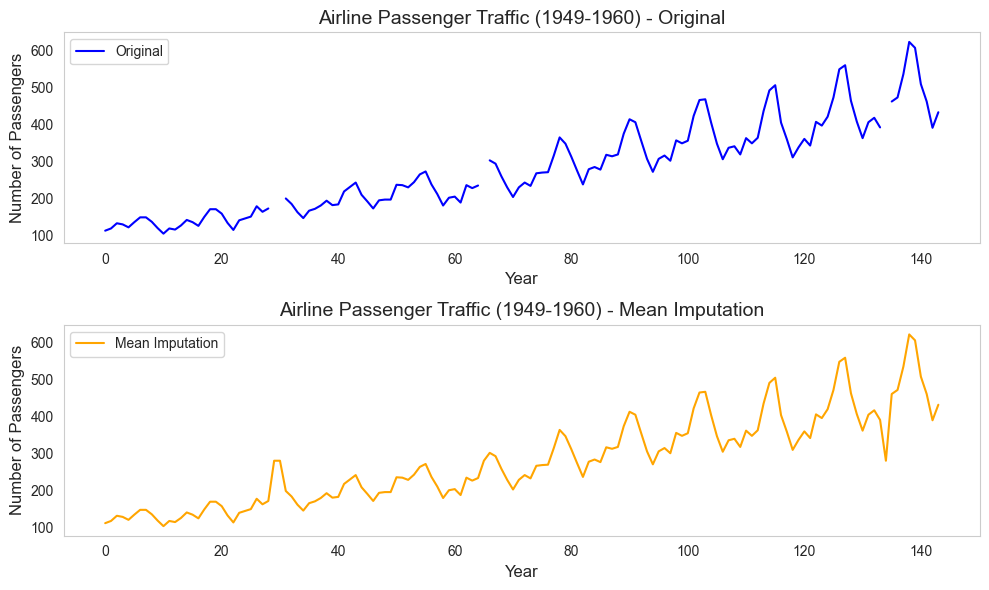

In [24]:
# Lets plot the Passengers_Mean_Imputation column Time series data
# Lets plot the original and mean imputed time series data together using subplots (2,1,i)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Airline Passenger Traffic (1949-1960) - Original', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.subplot(2,1,2)
plt.plot(data.index, data['Passengers_Mean_Imputation'], label='Mean Imputation', color='orange')
plt.title('Airline Passenger Traffic (1949-1960) - Mean Imputation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

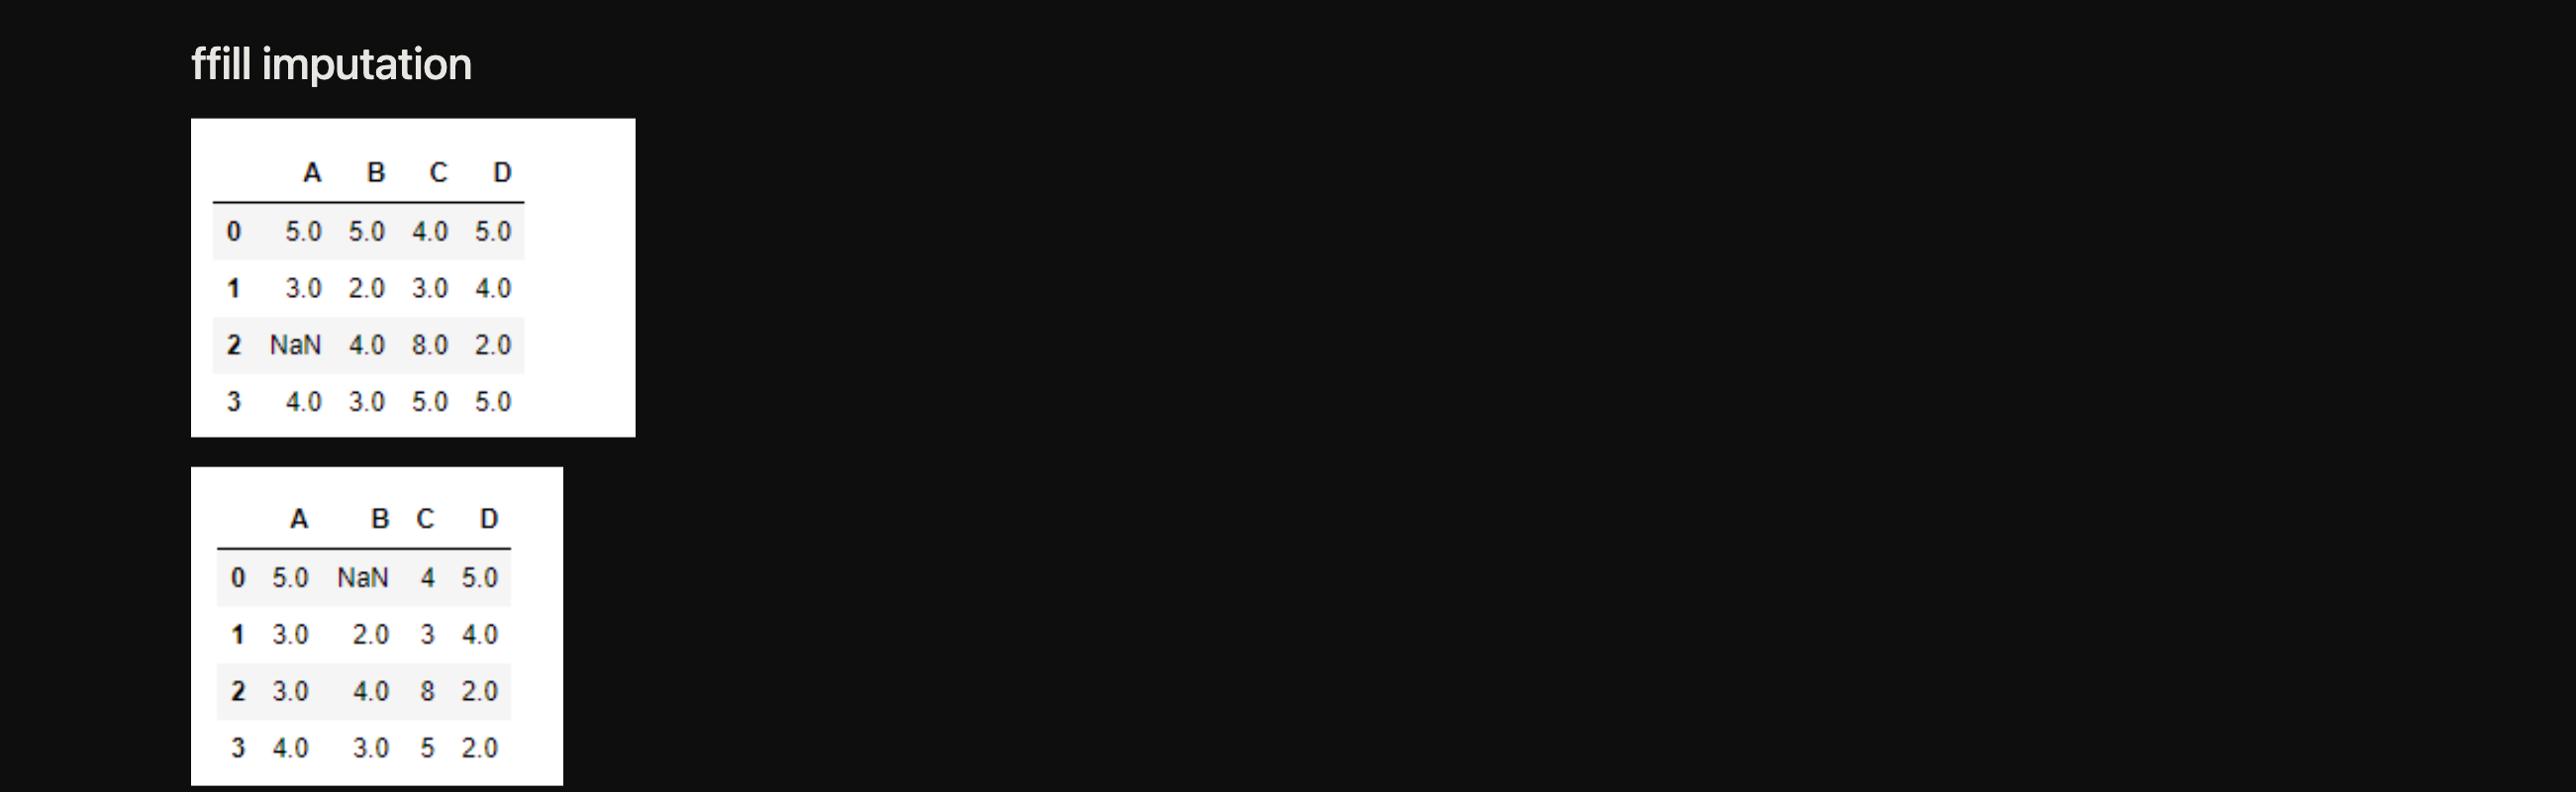

In [25]:
data = data.assign(Passengers_ffill_Imputation=data.Passengers.fillna(method="ffill"))
data.head()

,Month,Passengers,Passengers_Mean_Imputation,Passengers_ffill_Imputation
0,1949-01-01,112.0,112.0,112.0
1,1949-02-01,118.0,118.0,118.0
2,1949-03-01,132.0,132.0,132.0
3,1949-04-01,129.0,129.0,129.0
4,1949-05-01,121.0,121.0,121.0


In [26]:
# Lets look at the missing values again
data.isnull().sum()

Month                          0
Passengers                     4
Passengers_Mean_Imputation     0
Passengers_ffill_Imputation    0
dtype: int64

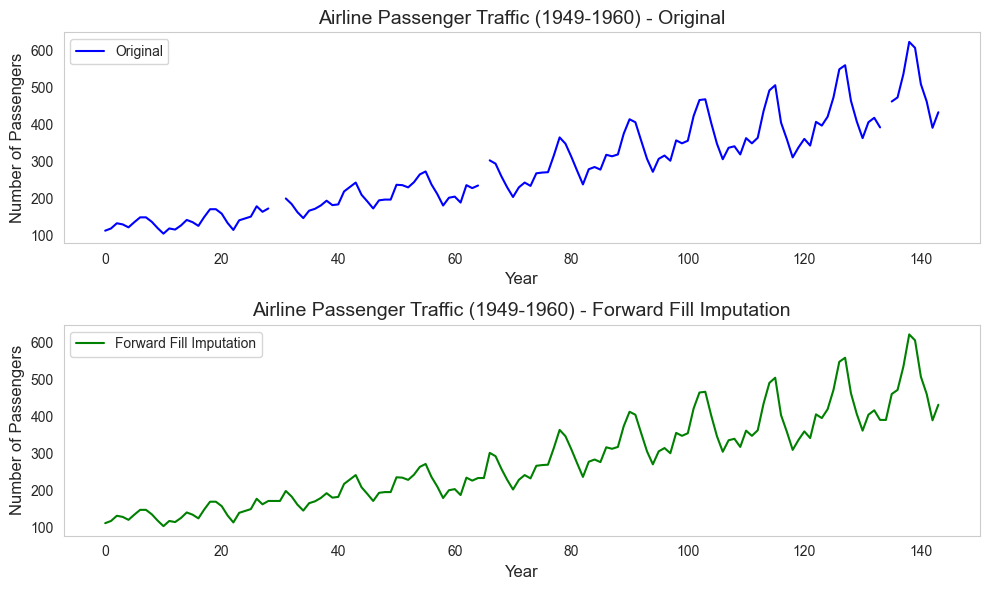

In [27]:
# Lets plot the Passengers_ffill_Imputation column Time series data
# Lets plot the original and Passengers_ffill_Imputation time series data together using subplots (2,1,i)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Airline Passenger Traffic (1949-1960) - Original', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.subplot(2,1,2)
plt.plot(data.index, data['Passengers_ffill_Imputation'], label='Forward Fill Imputation', color='green')
plt.title('Airline Passenger Traffic (1949-1960) - Forward Fill Imputation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# bfill imputation
data = data.assign(Passengers_bfill_Imputation=data.Passengers.fillna(method="bfill"))
data.head()

,Month,Passengers,Passengers_Mean_Imputation,Passengers_ffill_Imputation,Passengers_bfill_Imputation
0,1949-01-01,112.0,112.0,112.0,112.0
1,1949-02-01,118.0,118.0,118.0,118.0
2,1949-03-01,132.0,132.0,132.0,132.0
3,1949-04-01,129.0,129.0,129.0,129.0
4,1949-05-01,121.0,121.0,121.0,121.0


In [29]:
# Lets look at the missing values again
data.isnull().sum()

Month                          0
Passengers                     4
Passengers_Mean_Imputation     0
Passengers_ffill_Imputation    0
Passengers_bfill_Imputation    0
dtype: int64

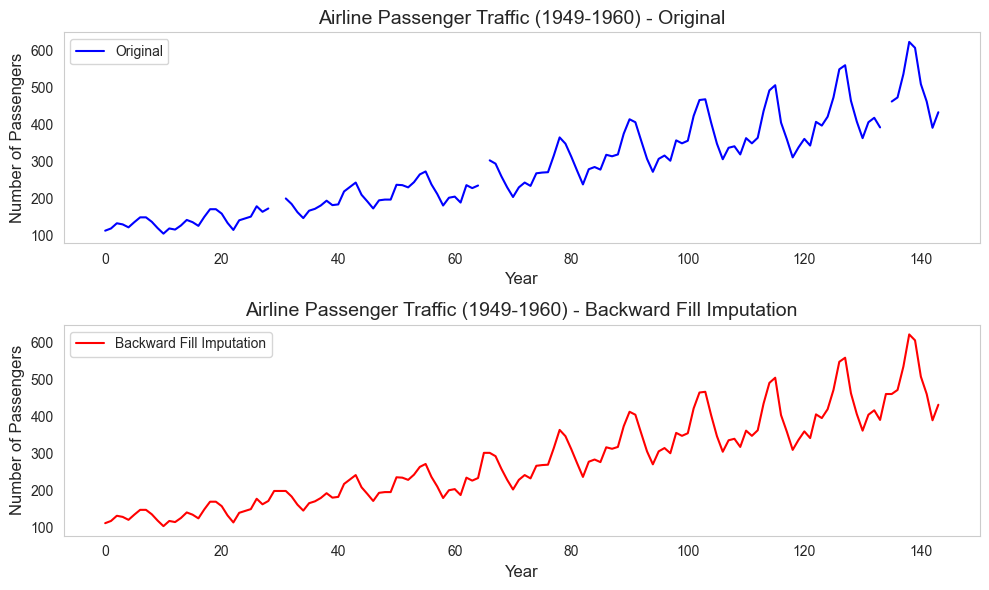

In [30]:
# Lets plot the data with Passengers_bfill_Imputation column
# Lets plot the original and Passengers_bfill_Imputation time series data together using subplots (2,1,i)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Airline Passenger Traffic (1949-1960) - Original', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.subplot(2,1,2)
plt.plot(data.index, data['Passengers_bfill_Imputation'], label='Backward Fill Imputation', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Backward Fill Imputation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# Linear interpolation
data = data.assign(Passengers_Linear_Interpolation=data.Passengers.interpolate(method='linear'))
data.head()

,Month,Passengers,Passengers_Mean_Imputation,Passengers_ffill_Imputation,Passengers_bfill_Imputation,Passengers_Linear_Interpolation
0,1949-01-01,112.0,112.0,112.0,112.0,112.0
1,1949-02-01,118.0,118.0,118.0,118.0,118.0
2,1949-03-01,132.0,132.0,132.0,132.0,132.0
3,1949-04-01,129.0,129.0,129.0,129.0,129.0
4,1949-05-01,121.0,121.0,121.0,121.0,121.0


In [32]:
# Lets look at the missing values again
data.isnull().sum()

Month                              0
Passengers                         4
Passengers_Mean_Imputation         0
Passengers_ffill_Imputation        0
Passengers_bfill_Imputation        0
Passengers_Linear_Interpolation    0
dtype: int64

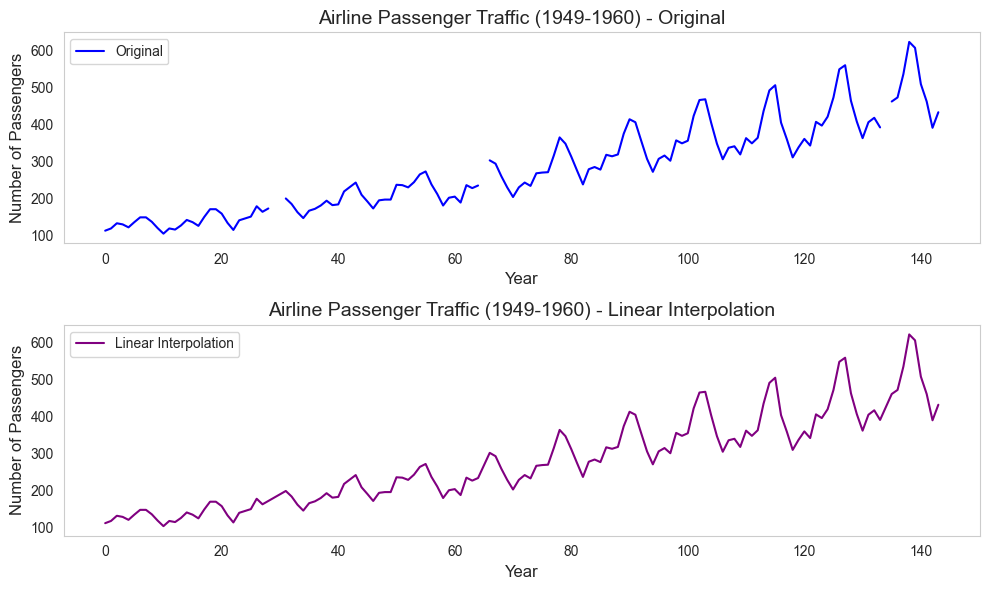

In [33]:
# Lets plot the original and mean imputed time series "Passengers_Linear_Interpolation" 

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Airline Passenger Traffic (1949-1960) - Original', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.subplot(2,1,2)
plt.plot(data.index, data['Passengers_Linear_Interpolation'], label='Linear Interpolation', color='purple')
plt.title('Airline Passenger Traffic (1949-1960) - Linear Interpolation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Spline interpolation - order 3
data = data.assign(Passengers_Spline_Interpolation=data.Passengers.interpolate(method='cubic'))
# order - 3 means cubic spline interpolation
# What is ideal value of order in spline interpolation? 
# The ideal value of order in spline interpolation depends on the specific dataset and the underlying patterns in the data. Generally, a cubic spline (order 3) is commonly used as it provides a good balance between flexibility and smoothness. However, for datasets with more complex patterns, higher-order splines may be considered, while for simpler datasets, lower-order splines may suffice. It is often recommended to experiment with different orders and evaluate the results to determine the best fit for the data.
data.head()

,Month,Passengers,Passengers_Mean_Imputation,Passengers_ffill_Imputation,Passengers_bfill_Imputation,Passengers_Linear_Interpolation,Passengers_Spline_Interpolation
0,1949-01-01,112.0,112.0,112.0,112.0,112.0,112.0
1,1949-02-01,118.0,118.0,118.0,118.0,118.0,118.0
2,1949-03-01,132.0,132.0,132.0,132.0,132.0,132.0
3,1949-04-01,129.0,129.0,129.0,129.0,129.0,129.0
4,1949-05-01,121.0,121.0,121.0,121.0,121.0,121.0


In [35]:
# Lets look at the missing values again
data.isnull().sum()

Month                              0
Passengers                         4
Passengers_Mean_Imputation         0
Passengers_ffill_Imputation        0
Passengers_bfill_Imputation        0
Passengers_Linear_Interpolation    0
Passengers_Spline_Interpolation    0
dtype: int64

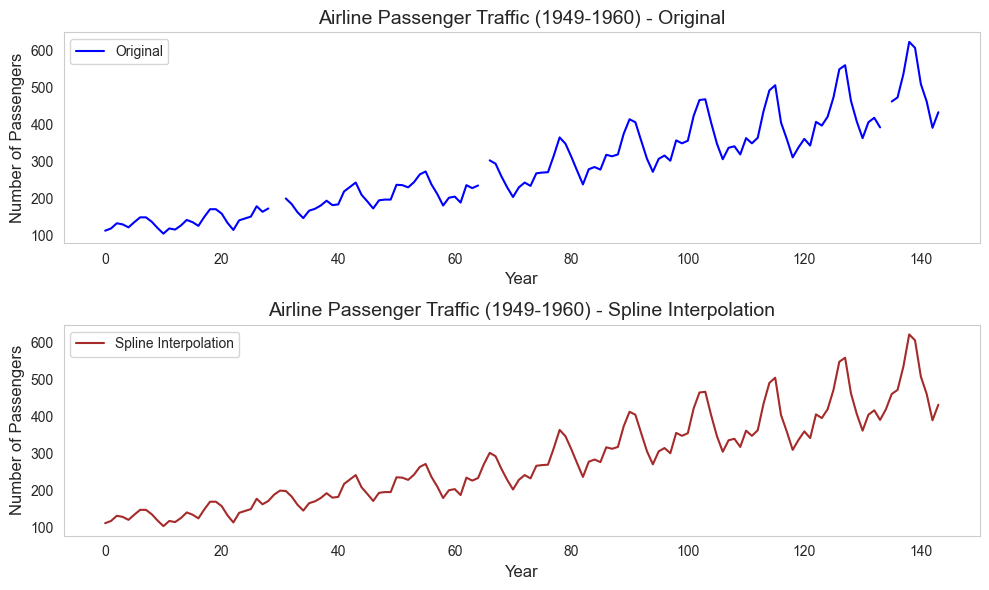

In [36]:
# Lets plot the original and mean imputed time series data together using subplots (2,1,i)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Airline Passenger Traffic (1949-1960) - Original', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.subplot(2,1,2)
plt.plot(data.index, data['Passengers_Spline_Interpolation'], label='Spline Interpolation', color='brown')
plt.title('Airline Passenger Traffic (1949-1960) - Spline Interpolation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Spline interpolation - order 5
data = data.assign(Passengers_Spline5_Interpolation=data.Passengers.interpolate(method='spline',order=5))
data.head()

,Month,Passengers,Passengers_Mean_Imputation,Passengers_ffill_Imputation,Passengers_bfill_Imputation,Passengers_Linear_Interpolation,Passengers_Spline_Interpolation,Passengers_Spline5_Interpolation
0,1949-01-01,112.0,112.0,112.0,112.0,112.0,112.0,112.0
1,1949-02-01,118.0,118.0,118.0,118.0,118.0,118.0,118.0
2,1949-03-01,132.0,132.0,132.0,132.0,132.0,132.0,132.0
3,1949-04-01,129.0,129.0,129.0,129.0,129.0,129.0,129.0
4,1949-05-01,121.0,121.0,121.0,121.0,121.0,121.0,121.0


In [38]:
# Lets look at the missing values again
data.isnull().sum()

Month                               0
Passengers                          4
Passengers_Mean_Imputation          0
Passengers_ffill_Imputation         0
Passengers_bfill_Imputation         0
Passengers_Linear_Interpolation     0
Passengers_Spline_Interpolation     0
Passengers_Spline5_Interpolation    0
dtype: int64

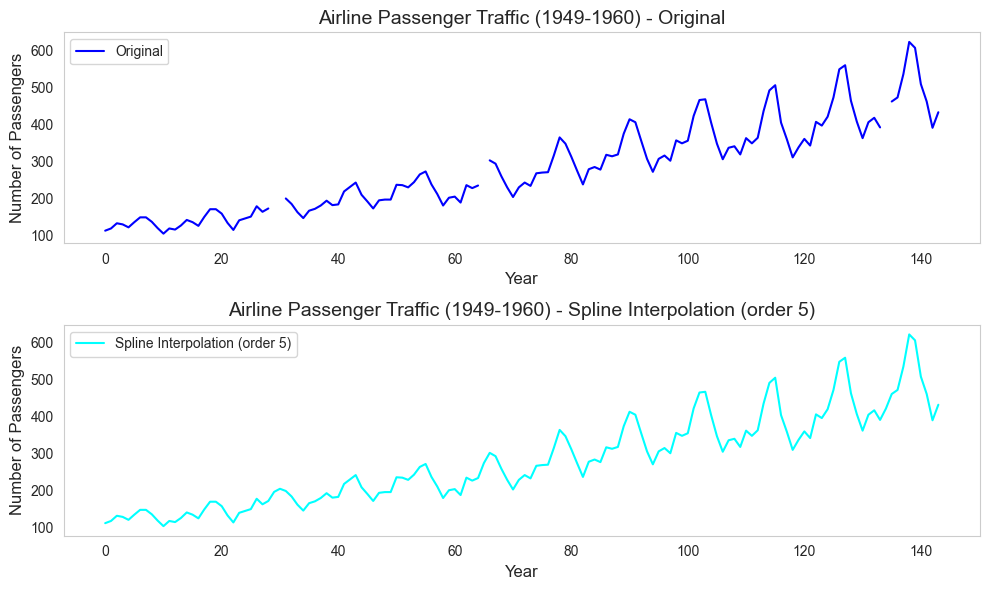

In [39]:
# Lets plot the original and mean imputed time series data with Passengers_Spline_Interpolation column
# Lets plot the original and mean imputed time series data together using subplots (2,1,i)

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(data.index, data['Passengers'], label='Original', color='blue')
plt.title('Airline Passenger Traffic (1949-1960) - Original', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.subplot(2,1,2)
plt.plot(data.index, data['Passengers_Spline5_Interpolation'], label='Spline Interpolation (order 5)', color='cyan')
plt.title('Airline Passenger Traffic (1949-1960) - Spline Interpolation (order 5)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Strategies for Handling Missing Values in Time Series Data and Their Justifications

Choosing the right strategy for handling missing values depends on the characteristics of the time series data, the nature of the missing data, and the analysis requirements. Here are detailed scenarios and justifications for using different imputation methods:

### 1. Forward Fill (Last Observation Carried Forward - LOCF)
- **Scenario**: The time series has a stable trend or missing values occur sporadically.
- **Justification**: This method assumes that the last observed value is a good estimate for the missing value, which is reasonable in a stable trend.
- **Example**: In daily stock prices, if a value is missing for one day, using the last observed price (from the previous day) can provide a reasonable estimate, especially in a stable market.

### 2. Backward Fill (Next Observation Carried Backward - NOCB)
- **Scenario**: Missing values occur at the beginning of the time series or when the trend is stable.
- **Justification**: This method assumes the next observed value can fill the missing gaps effectively, especially when initial data points are missing.
- **Example**: In a new product's sales data, if the first few days' sales data are missing, using the sales figure from the earliest available day provides a reasonable starting point.

### 3. Mean Imputation
- **Scenario**: Missing values are randomly distributed and do not significantly affect the overall trend or seasonality.
- **Justification**: Using the mean of observed values can smooth out random missing values without introducing bias.
- **Example**: For annual average temperature readings, if a few daily records are missing, replacing them with the year's average temperature helps maintain the overall trend without introducing significant errors.

### 4. Interpolation
- **Scenario**: The time series has a smooth trend, and missing values occur within a short span.
- **Justification**: Interpolation provides a reasonable estimate by leveraging the values before and after the missing points, maintaining the continuity of the trend.
- **Example**: In monthly rainfall data, if the value for March is missing, linear interpolation can estimate the missing value based on February and April data, preserving the trend.

### 5. Seasonal Imputation
- **Scenario**: The time series exhibits clear seasonal patterns, and missing values occur during specific seasons.
- **Justification**: Replacing missing values with the corresponding seasonal values from previous years leverages the inherent seasonality in the data.
- **Example**: In retail sales data with strong seasonal patterns (e.g., increased sales in December due to holidays), missing December sales data can be replaced with the average sales from previous Decembers, preserving the seasonal effect.

### 6. Machine Learning Methods
- **Scenario**: Missing values are complex, cannot be easily filled using simpler methods, and there are sufficient observed data points to train the model.
- **Justification**: Machine learning models can capture complex relationships and provide accurate estimates by leveraging multiple features and historical data.
- **Example**: For predicting missing values in housing prices, a regression model using features like location, size, and nearby amenities can provide accurate estimates, accounting for the complex interactions between these features.

### Detailed Examples and Justifications

#### Example 1: Retail Sales Data
- **Scenario**: Monthly sales data for a retail store over 5 years, with missing values in random months.
- **Strategy**: Seasonal Imputation
- **Justification**: Retail sales often have seasonal patterns (e.g., higher sales in December). Using seasonal imputation, missing sales data for December can be replaced with average sales from previous Decembers, preserving seasonal trends.

#### Example 2: Daily Temperature Data
- **Scenario**: Daily temperature readings over a year, with some random missing days.
- **Strategy**: Interpolation
- **Justification**: Temperature data usually follows a smooth trend. Linear interpolation can estimate the missing temperatures based on the readings from adjacent days, maintaining the trend's continuity.

#### Example 3: Stock Price Data
- **Scenario**: Daily stock prices with a few missing days due to market holidays.
- **Strategy**: Forward Fill (LOCF)
- **Justification**: Stock prices can be relatively stable over short periods. Using the last observed price to fill in the missing days can provide a reasonable estimate without introducing significant errors.

#### Example 4: Website Traffic Data
- **Scenario**: Hourly website traffic data with missing values during certain hours due to server downtime.
- **Strategy**: Mean Imputation
- **Justification**: If the missing hours are randomly distributed, using the mean traffic can provide a neutral estimate without affecting the overall trend significantly.

#### Example 5: Agricultural Yield Data
- **Scenario**: Annual yield data for a crop over several decades, with missing values in some years.
- **Strategy**: Machine Learning Methods
- **Justification**: Yield data can be influenced by various factors like weather, soil quality, and farming practices. A regression model using these features can predict the missing yields more accurately than simpler methods.

### Conclusion

The choice of imputation method should be guided by the characteristics of the time series data, the nature of the missing values, and the specific requirements of the analysis. By selecting the appropriate strategy, you can ensure that the imputed values preserve the integrity and accuracy of the time series data.

In [40]:
# Use linear interpolation to impute missing values
data.head()

,Month,Passengers,Passengers_Mean_Imputation,Passengers_ffill_Imputation,Passengers_bfill_Imputation,Passengers_Linear_Interpolation,Passengers_Spline_Interpolation,Passengers_Spline5_Interpolation
0,1949-01-01,112.0,112.0,112.0,112.0,112.0,112.0,112.0
1,1949-02-01,118.0,118.0,118.0,118.0,118.0,118.0,118.0
2,1949-03-01,132.0,132.0,132.0,132.0,132.0,132.0,132.0
3,1949-04-01,129.0,129.0,129.0,129.0,129.0,129.0,129.0
4,1949-05-01,121.0,121.0,121.0,121.0,121.0,121.0,121.0


In [41]:
data.columns

Index(['Month', 'Passengers', 'Passengers_Mean_Imputation',
       'Passengers_ffill_Imputation', 'Passengers_bfill_Imputation',
       'Passengers_Linear_Interpolation', 'Passengers_Spline_Interpolation',
       'Passengers_Spline5_Interpolation'],
      dtype='object')

In [42]:
data.drop([
    'Passengers', 'Passengers_Mean_Imputation',
       'Passengers_ffill_Imputation', 'Passengers_bfill_Imputation',
        'Passengers_Spline_Interpolation',
       'Passengers_Spline5_Interpolation'
],
          axis=1,
          inplace=True)
data.columns

Index(['Month', 'Passengers_Linear_Interpolation'], dtype='object')

In [43]:
data.head()

,Month,Passengers_Linear_Interpolation
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


In [44]:
data.rename(columns={'Passengers_Linear_Interpolation':'Passengers'},inplace=True)

In [45]:
data.set_index('Month',inplace=True)
data.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [46]:
# Lets check for missing values again
data.isnull().sum()

Passengers    0
dtype: int64

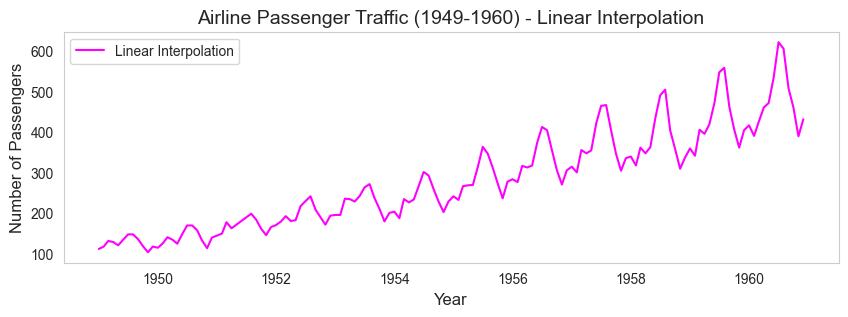

In [47]:
# Lets plot the Passengers column Time series data after imputation

plt.figure(figsize=(10,3))
plt.plot(data.index, data['Passengers'], label='Linear Interpolation', color='magenta')
plt.title('Airline Passenger Traffic (1949-1960) - Linear Interpolation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

## Outlier Detection and Handling in Time Series

Outliers in time series data can significantly affect analysis and forecasting. Therefore, identifying and appropriately handling outliers is crucial. Here's a detailed explanation of various methods for outlier detection and handling, along with examples and scenarios.

### Outlier Detection Methods

#### 1. Visual Inspection
- **Description**: Plot the time series data and visually inspect for data points that deviate significantly from the overall pattern. Outliers may appear as unusually high or low spikes in the data.
- **Example**: Plotting daily sales data and noticing a sudden spike in sales during a particular day which does not align with the usual trend.
- **Scenario**: Retail sales data where promotional events cause sudden, temporary spikes in sales.

#### 2. Statistical Methods
- **Description**: Calculate statistics like mean, median, standard deviation, and quartiles, and identify data points that fall far outside the expected range based on these statistics.
- **Example**: Calculating the interquartile range (IQR) and identifying values that fall beyond 1.5 * IQR above the third quartile or below the first quartile as outliers.
- **Scenario**: Monthly temperature data where readings significantly deviating from the mean (e.g., a sudden temperature drop or rise) are considered outliers.

#### 3. Time Series Decomposition
- **Description**: Decompose the time series into trend, seasonal, and residual components. Analyze the residual component for any unusually large deviations, which could indicate outliers.
- **Example**: Using seasonal decomposition to separate a time series of monthly electricity consumption into trend, seasonal, and residual parts, then inspecting the residuals for anomalies.
- **Scenario**: Utility consumption data where unexpected surges or drops in usage could indicate outliers due to meter faults or data entry errors.

#### 4. Machine Learning Models
- **Description**: Train machine learning models such as Isolation Forest, One-Class SVM, or Local Outlier Factor to automatically detect outliers based on underlying patterns in the time series data.
- **Example**: Using an Isolation Forest model to identify outliers in a financial time series dataset.
- **Scenario**: Stock price data where abrupt, unusual changes in prices can be flagged as potential outliers using machine learning techniques.

### Outlier Handling Methods

#### 1. Trimming or Winsorization
- **Trimming**: Remove extreme values from the dataset.
- **Winsorization**: Replace outliers with the nearest non-outlying values within a specified range.
- **Example**: If daily sales data contains extreme values, trimming removes these values, while Winsorization replaces them with the nearest value within the interquartile range.
- **Scenario**: Financial transaction data where extremely high or low values due to errors or fraud are trimmed or Winsorized.

#### 2. Transformation
- **Description**: Apply mathematical transformations to stabilize variance and reduce the impact of outliers.
- **Example**: Applying a log transformation to sales data to reduce the effect of extremely high sales days.
- **Scenario**: Revenue data where large outliers can distort analysis, and transformations like log or Box-Cox help in mitigating their impact.

#### 3. Imputation
- **Description**: Replace outliers with imputed values based on neighboring data points or predicted values from a model.
- **Example**: Using linear interpolation to replace outliers in temperature data with estimated values based on surrounding data points.
- **Scenario**: Sensor data from environmental monitoring where occasional faulty readings are replaced with interpolated values.

#### 4. Robust Statistical Measures
- **Description**: Use robust statistical measures such as median or interquartile range (IQR), which are less sensitive to outliers.
- **Example**: Using the median instead of the mean to summarize central tendency in the presence of outliers in housing price data.
- **Scenario**: Income data where extreme outliers (e.g., very high incomes) can skew the mean, making the median a more reliable measure.

### Choosing the Appropriate Method

#### Initial Detection
- **Visual Inspection**: Good for an initial, quick check, especially when data volume is manageable.
- **Statistical Methods**: Effective for systematic identification based on data distribution.
- **Time Series Decomposition**: Useful for time series with clear seasonal patterns.
- **Machine Learning Models**: Suitable for complex time series with non-linear patterns and multiple features.

#### Handling Outliers
- **Trimming or Winsorization**: Use when extreme values are likely errors and removing or limiting them won't affect the overall analysis significantly.
- **Transformation**: Suitable when the dataset has a wide range of values and a few extreme values that need mitigation.
- **Imputation**: Effective when maintaining data continuity is crucial, and outliers are isolated events.
- **Robust Statistical Measures**: Ideal for summarizing data when outliers are present but need to be minimized in their impact.

### Detailed Examples and Justifications

#### Example 1: Retail Sales Data
- **Detection**: Visual inspection and statistical methods can identify sales spikes during holiday seasons as outliers.
- **Handling**: Winsorization can be used to replace extreme sales values with the nearest non-extreme values to maintain a more consistent dataset for trend analysis.

#### Example 2: Temperature Data
- **Detection**: Time series decomposition can separate seasonal trends and identify outliers in residuals.
- **Handling**: Imputation via linear interpolation can replace outliers with values that fit the overall temperature trend, ensuring continuity.

#### Example 3: Financial Data
- **Detection**: Machine learning models like Isolation Forest can detect unusual stock price changes.
- **Handling**: Log transformation can reduce the impact of extreme price changes, stabilizing variance for more robust analysis.

#### Example 4: Sensor Data
- **Detection**: Statistical methods can flag readings beyond typical operational ranges as outliers.
- **Handling**: Robust statistical measures like the median can summarize data without being affected by occasional faulty readings.

By selecting and applying the appropriate detection and handling methods, you can ensure that outliers are effectively managed, preserving the accuracy and reliability of time series analyses.

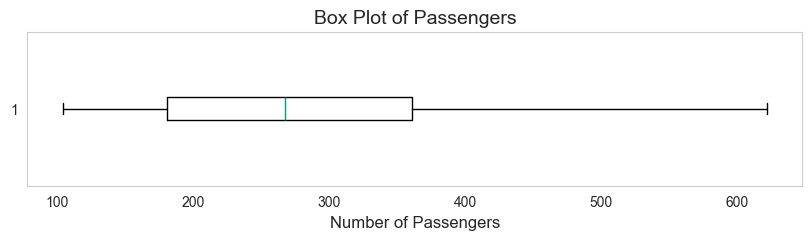

In [48]:
# Box plot and interquartile range

plt.figure(figsize=(10,2))
plt.boxplot(data['Passengers'], vert=False)
plt.title('Box Plot of Passengers', fontsize=14)
plt.xlabel('Number of Passengers', fontsize=12)
plt.grid()
plt.show()

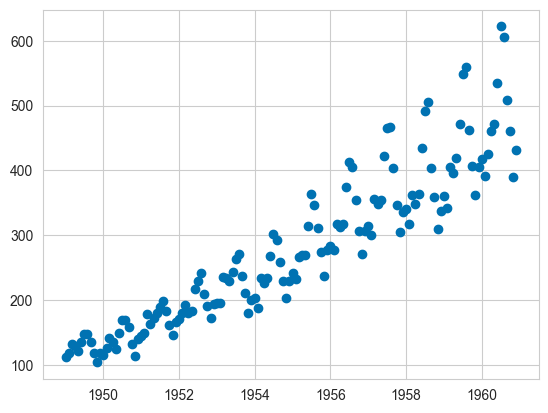

In [49]:
plt.scatter(data.index,data.Passengers)
plt.show()

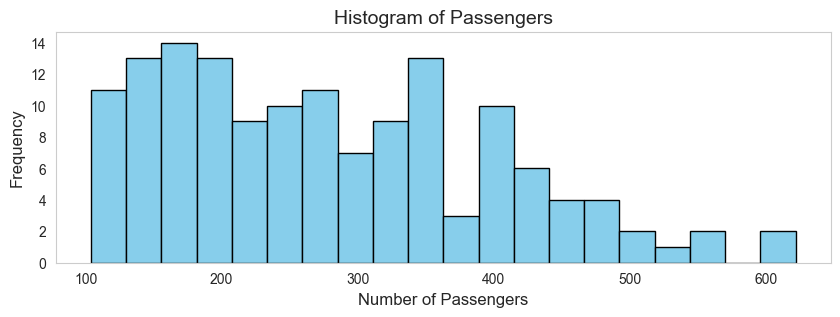

In [50]:
# Histogram plot

plt.figure(figsize=(10,3))
plt.hist(data['Passengers'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Passengers', fontsize=14)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid()
plt.show()

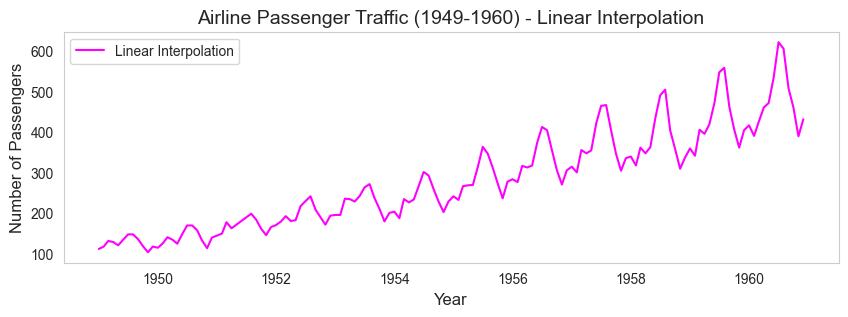

In [51]:
# Lets plot the Passengers column Time series data after imputation

plt.figure(figsize=(10,3))
plt.plot(data.index, data['Passengers'], label='Linear Interpolation', color='magenta')
plt.title('Airline Passenger Traffic (1949-1960) - Linear Interpolation', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

## Time series Decomposition

### Time Series Decomposition: Additive and Multiplicative

Time series decomposition is a method used to break down a time series into its fundamental components, allowing for better understanding and analysis. The primary components are:

- **Trend**: The long-term progression of the series.
- **Seasonality**: The repeating short-term cycle within the series.
- **Residual**: The random noise or irregularities in the series.

There are two main types of time series decomposition: additive and multiplicative. The choice between them depends on the nature of the relationship between the components.

### Additive Decomposition

In an additive model, the components of the time series are assumed to add together linearly. The model can be expressed as:
\[ Y_t = T_t + S_t + R_t \]
where:
- \( Y_t \) is the observed value at time \( t \).
- \( T_t \) is the trend component at time \( t \).
- \( S_t \) is the seasonal component at time \( t \).
- \( R_t \) is the residual component at time \( t \).

#### Example

Consider a monthly sales dataset that shows a clear upward trend over several years with repeating seasonal patterns.

1. **Trend Component**: This shows the general increase in sales over time.
2. **Seasonal Component**: This captures the periodic fluctuations, such as increased sales during holidays.
3. **Residual Component**: This includes any irregularities or random variations not explained by the trend or seasonality.

#### Use Case

Additive decomposition is appropriate when the seasonal variation is relatively constant over time. For example, a retail store's monthly sales data might show a consistent seasonal pattern (e.g., higher sales in December), and an overall upward trend due to growth in the business.

### Multiplicative Decomposition

In a multiplicative model, the components of the time series are assumed to multiply together. The model can be expressed as:
\[ Y_t = T_t \times S_t \times R_t \]
or, in log form:
\[ \log(Y_t) = \log(T_t) + \log(S_t) + \log(R_t) \]

#### Example

Consider a monthly airline passenger dataset that shows an exponential growth trend and a seasonal pattern where the magnitude of seasonal variation increases over time.

1. **Trend Component**: This shows the exponential growth in the number of passengers over time.
2. **Seasonal Component**: This captures the increasing seasonal fluctuations, such as higher passenger numbers in summer months.
3. **Residual Component**: This includes any irregularities or random variations not explained by the trend or seasonality.

#### Use Case

Multiplicative decomposition is suitable when the seasonal variation changes proportionally with the level of the series. For example, an airline's passenger data might show a trend of increasing passenger numbers, with larger seasonal fluctuations (more pronounced peaks and troughs) as the overall number of passengers grows.

### Steps for Time Series Decomposition

1. **Identify the Model**: Determine whether an additive or multiplicative model is appropriate based on the nature of the data.
2. **Estimate Components**: Use statistical methods or software tools to estimate the trend, seasonal, and residual components.
3. **Analyze Components**: Examine each component to understand the underlying patterns in the time series.
4. **Reconstruct Series**: Combine the components to reconstruct the original series and validate the decomposition.

### Detailed Example: Monthly Sales Data (Additive Model)

Suppose we have monthly sales data for a retail store over three years.

1. **Trend Component**:
   - Calculate the moving average to smooth out the fluctuations and highlight the trend.
   - Example: The trend shows a steady increase in sales due to market expansion.

2. **Seasonal Component**:
   - Subtract the trend component from the original data to isolate the seasonal effects.
   - Example: Each December shows a spike in sales due to holiday shopping, while sales dip in January.

3. **Residual Component**:
   - Subtract both the trend and seasonal components from the original data to get the residuals.
   - Example: Random fluctuations in sales due to promotional events or external factors.

### Detailed Example: Monthly Airline Passengers (Multiplicative Model)

Suppose we have monthly data on the number of passengers for an airline over several years.

1. **Trend Component**:
   - Use a moving average or other smoothing techniques to estimate the trend.
   - Example: The trend shows exponential growth as the airline expands its routes.

2. **Seasonal Component**:
   - Divide the original data by the trend component to isolate the seasonal effects.
   - Example: Summer months consistently show higher passenger numbers, with the effect becoming more pronounced over time.

3. **Residual Component**:
   - Divide the original data by both the trend and seasonal components to get the residuals.
   - Example: Irregularities in passenger numbers due to events like economic downturns or changes in travel regulations.

### Conclusion

Time series decomposition, whether additive or multiplicative, is a powerful tool for understanding and analyzing time series data. By breaking down the data into trend, seasonal, and residual components, you can gain insights into the underlying patterns and make more accurate forecasts. The choice between additive and multiplicative models depends on the nature of the data and the relationship between its components.

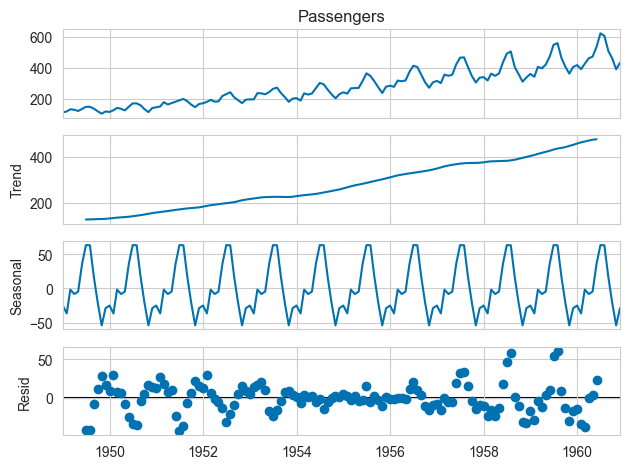

In [52]:
# Additive seasonal decomposition
import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(data.Passengers, model='additive') 
# seasonal_decompose() function is used to decompose a time series into its components: trend, seasonal, and residual. The 'model' parameter specifies the type of decomposition, which can be either 'additive' or 'multiplicative'. In this case, we are using 'additive' decomposition, which assumes that the components are added together to form the original time series. The result of the decomposition is stored in the 'decomposition' variable, which contains the trend, seasonal, and residual components of the time series.

fig = decomposition.plot()
plt.show()

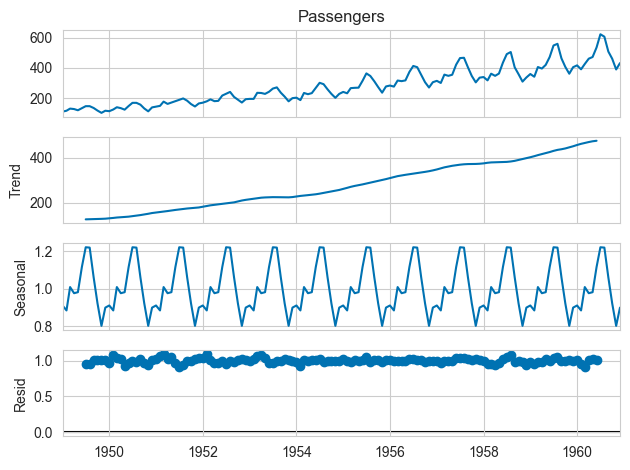

In [53]:
# Multiplicative seasonal decomposition

decomposition = sm.tsa.seasonal_decompose(data.Passengers, 
                                          model='multiplicative') 
                                        # multiplicative seasonal index
fig = decomposition.plot()
plt.show()

# Build and evaluate time series forecast

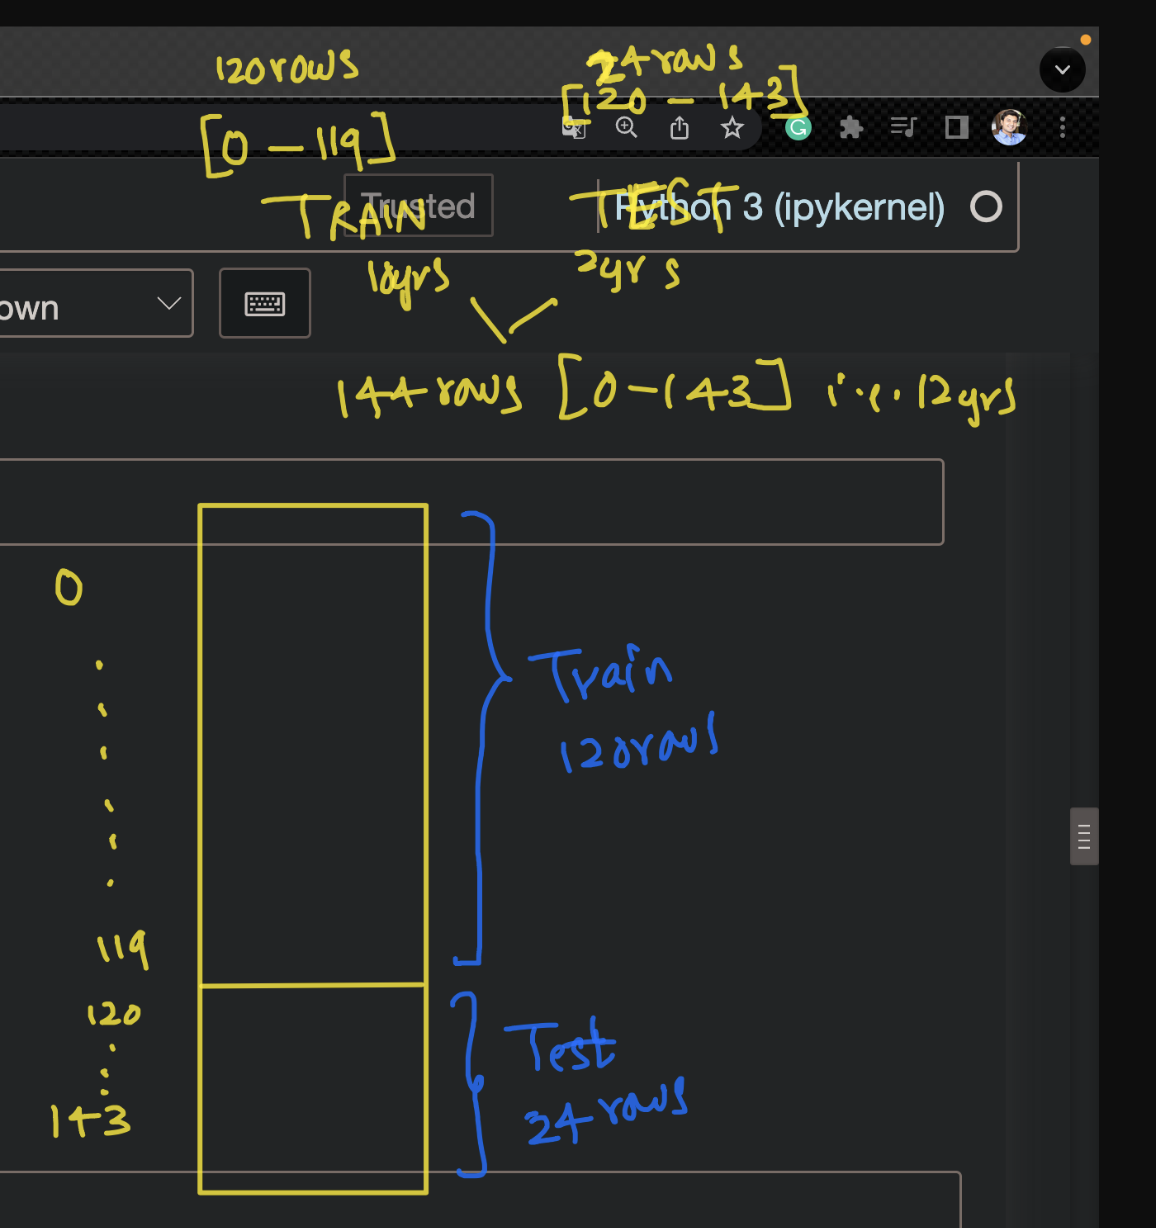

## Split time series data into training and test set

In time series forecasting, data should not be shuffled because the temporal order of the observations is crucial for making accurate predictions. Here are the detailed reasons:

### 1. **Temporal Dependency**
- **Description**: Time series data inherently relies on the sequential order of observations. Each data point is often dependent on previous data points.
- **Example**: Consider stock prices: the price today is influenced by the prices on previous days. Shuffling the data would break this temporal relationship, rendering the data meaningless for forecasting purposes.

### 2. **Trend and Seasonality**
- **Description**: Time series data often exhibit trends (long-term increase or decrease) and seasonality (repeating patterns over specific periods). Maintaining the order is essential to identify and model these components accurately.
- **Example**: Monthly sales data may show an upward trend over years and seasonal spikes during holiday seasons. Shuffling this data would obscure these patterns, making it impossible to model the trend and seasonality correctly.

### 3. **Autocorrelation**
- **Description**: Time series data often show autocorrelation, where the current value is correlated with its past values. Shuffling disrupts this autocorrelation structure, which is vital for many time series models.
- **Example**: In weather forecasting, today's temperature is often correlated with yesterday's temperature. Shuffling the data would eliminate this autocorrelation, making it challenging to model the temperature accurately.

### 4. **Model Training and Evaluation**
- **Description**: Time series models, such as ARIMA, exponential smoothing, and LSTM networks, rely on the sequential nature of the data for training and forecasting. Shuffling would mislead these models during the learning phase.
- **Example**: When training an ARIMA model, it uses the order of observations to establish the relationship between time points. If the data were shuffled, the model would fail to capture these relationships correctly, leading to poor forecasts.

### 5. **Forecasting Horizon**
- **Description**: In time series forecasting, we aim to predict future values based on past observations. Maintaining the chronological order ensures that the model learns from past data to make future predictions.
- **Example**: In energy consumption forecasting, past consumption data helps predict future usage. If the data is shuffled, the model can't distinguish between past and future, defeating the purpose of forecasting.

### Practical Example

#### Scenario: Monthly Sales Data
Consider a dataset of monthly sales data for a retail store over five years. The goal is to forecast sales for the next 12 months.

- **Unshuffled Data**: The model learns from the sequential data, identifying trends (e.g., increasing sales over the years) and seasonal patterns (e.g., higher sales in December). It can then accurately forecast future sales based on these learned patterns.

- **Shuffled Data**: If the data is shuffled, the temporal order is lost. The model would see January data from one year next to July data from another year, disrupting the trend and seasonal patterns. Consequently, the model would fail to make accurate predictions as it no longer has a coherent temporal structure to learn from.

### Conclusion

Shuffling data in a time series forecasting problem disrupts the inherent temporal dependencies, trends, seasonality, and autocorrelation structures critical for accurate modeling and forecasting. Maintaining the chronological order of data is essential for the integrity and accuracy of time series analysis and forecasting.|

In [54]:
data.shape

(144, 1)

In [55]:
data.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [56]:
train_len = 120
train = data[0:train_len] # first 120 months as training set, i.e. 0 to 119
test = data[train_len:] # last 24 months as out-of-time test set i.e. 120 to end

In [57]:
train.shape

(120, 1)

In [58]:
train.head()

,Passengers
Month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


In [59]:
test.head()

,Passengers
Month,
1959-01-01,360.0
1959-02-01,342.0
1959-03-01,406.0
1959-04-01,396.0
1959-05-01,420.0


In [60]:
test.shape

(24, 1)

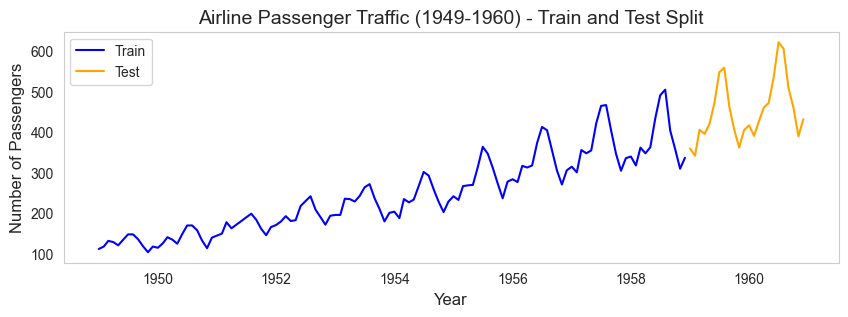

In [61]:
# Lets plot the train and test time series data together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.title('Airline Passenger Traffic (1949-1960) - Train and Test Split', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

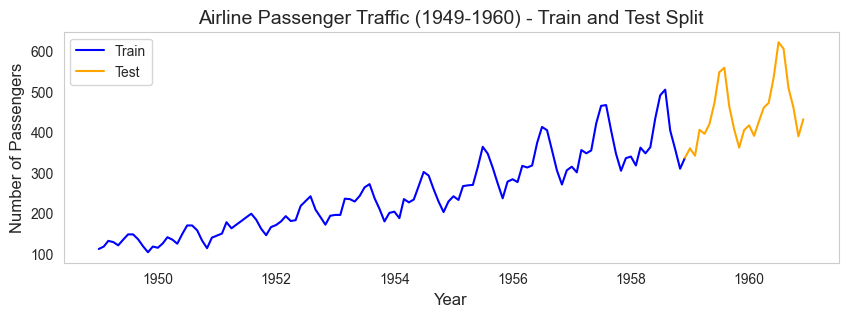

In [62]:
# Lets plot the train and test time series data together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')

# connect last point
plt.plot([train.index[-1], test.index[0]],
         [train['Passengers'].iloc[-1], test['Passengers'].iloc[0]],
         color='orange') # train.index[-1] is 119th month, test.index[0] is 120th month

plt.title('Airline Passenger Traffic (1949-1960) - Train and Test Split', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [63]:
# Simple time series methods
# Naive method
# What is the naive method in time series forecasting?
# The naive method in time series forecasting is a simple approach where the forecast for the next time period is assumed to be the same as the last observed value. In other words, it assumes that the future value will be equal to the most recent value in the time series. This method is often used as a baseline for evaluating the performance of more complex forecasting models.

print(train_len-1) # (120-1)
print(train.iloc[119]) # 119th month

119
Passengers    337.0
Name: 1958-12-01 00:00:00, dtype: float64


In [64]:
y_hat_naive = test.copy()
y_hat_naive['naive_forecast'] = train['Passengers'][train_len-1]
y_hat_naive

,Passengers,naive_forecast
Month,,
1959-01-01,360.0,337.0
1959-02-01,342.0,337.0
1959-03-01,406.0,337.0
1959-04-01,396.0,337.0
1959-05-01,420.0,337.0
1959-06-01,472.0,337.0
1959-07-01,548.0,337.0
1959-08-01,559.0,337.0
1959-09-01,463.0,337.0


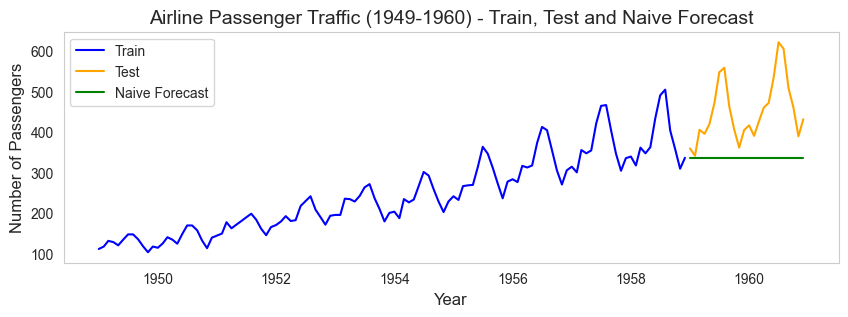

In [65]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_naive.index, y_hat_naive['naive_forecast'], label='Naive Forecast', color='green')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Naive Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [66]:
# Calculate RMSE and MAPE

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(
    mean_squared_error(test['Passengers'],
                       y_hat_naive['naive_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_naive['naive_forecast']) /
        test['Passengers']) * 100, 2)

results = pd.DataFrame({
    'Method': ['Naive method'],
    'MAPE': [mape],
    'RMSE': [rmse]
})
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63


In [67]:
# Simple average method

print(train['Passengers'].mean())
y_hat_avg = test.copy()
y_hat_avg['avg_forecast'] = train['Passengers'].mean()
y_hat_avg

245.89166666666668


,Passengers,avg_forecast
Month,,
1959-01-01,360.0,245.891667
1959-02-01,342.0,245.891667
1959-03-01,406.0,245.891667
1959-04-01,396.0,245.891667
1959-05-01,420.0,245.891667
1959-06-01,472.0,245.891667
1959-07-01,548.0,245.891667
1959-08-01,559.0,245.891667
1959-09-01,463.0,245.891667


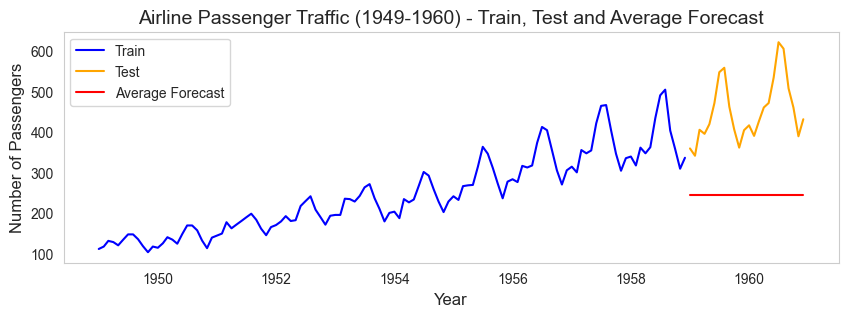

In [68]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_avg['avg_forecast'], label='Average Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Average Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [69]:
# Calculate RMSE and MAPE

rmse = np.sqrt(
    mean_squared_error(test['Passengers'], y_hat_avg['avg_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_avg['avg_forecast']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Simple average method'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28


In [70]:
# Simple moving average method

y_hat_sma = data.copy()
ma_window = 12
y_hat_sma['sma_forecast'] = data['Passengers'].rolling(ma_window).mean()
y_hat_sma['sma_forecast'][train_len:] = y_hat_sma['sma_forecast'][train_len-1]
y_hat_sma

,Passengers,sma_forecast
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,NaN
1949-03-01,132.0,NaN
1949-04-01,129.0,NaN
1949-05-01,121.0,NaN
...,...,...
1960-08-01,606.0,381.0
1960-09-01,508.0,381.0
1960-10-01,461.0,381.0


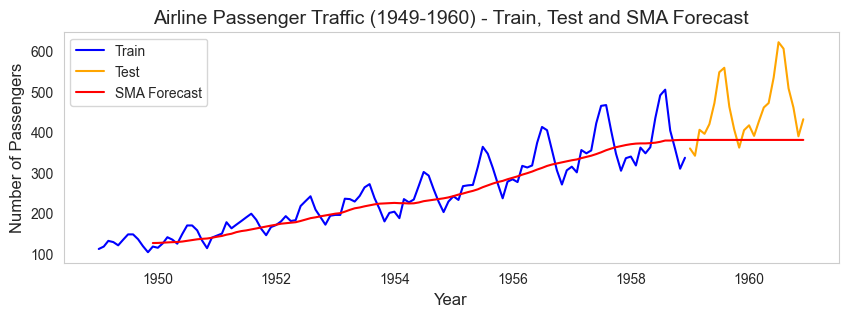

In [71]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_sma['sma_forecast'], label='SMA Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and SMA Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [72]:
# Calculate RMSE and MAPE

rmse = np.sqrt(
    mean_squared_error(test['Passengers'],
                       y_hat_sma['sma_forecast'][train_len:])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_sma['sma_forecast'][train_len:]) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Simple moving average forecast'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54


In [73]:
# Exponential smoothing methods
# What is exponential smoothing in time series forecasting?
# Exponential smoothing in time series forecasting is a technique that applies weighted averages to past observations, where the weights decrease exponentially as the observations get older. This method gives more importance to recent data points while still considering the entire history of the time series. Exponential smoothing is commonly used for forecasting and can be applied in various forms, such as simple exponential smoothing, Holt's linear trend method, and Holt-Winters seasonal method, depending on the characteristics of the time series data.

# There are three types of exponential smoothing methods:
# 1. Simple Exponential Smoothing: This method is used for time series data without any trend or seasonality. It applies a weighted average to past observations, where the weights decrease exponentially as the observations get older. The forecast is calculated using the formula: 
#    Forecast(t) = α * Actual(t-1) + (1 - α) * Forecast(t-1)
# Level is captured using α

# 2. Holt's Linear Trend Method: This method is used for time series data with a linear trend but no seasonality. It extends simple exponential smoothing by adding a second equation to capture the trend. The forecast is calculated using the formulas:
#    Level(t) = α * Actual(t) + (1 - α) * (Level(t-1) + Trend(t-1))
#    Trend(t) = β * (Level(t) - Level(t-1)) + (1 - β) * Trend(t-1)
#    Forecast(t+h) = Level(t) + h * Trend(t)
# Level is captured using α and trend is captured using β

# 3. Holt-Winters Seasonal Method: This method is used for time series data with both trend and seasonality. It extends Holt's linear trend method by adding a third equation to capture the seasonal component. The forecast is calculated using the formulas:
#    Level(t) = α * (Actual(t) / Seasonal(t-s)) + (1 - α) * (Level(t-1) + Trend(t-1))
#    Trend(t) = β * (Level(t) - Level(t-1)) + (1 - β) * Trend(t-1)
#    Seasonal(t) = γ * (Actual(t) / Level(t)) + (1 - γ) * Seasonal(t-s)
#    Forecast(t+h) = (Level(t) + h * Trend(t)) * Seasonal(t+h-s)
# Level is captured using α, trend is captured using β and seasonality is captured using γ

In [74]:
# Simple exponential smoothing

from statsmodels.tsa.holtwinters import SimpleExpSmoothing
model = SimpleExpSmoothing(train['Passengers'])
model_fit = model.fit(smoothing_level=0.2,optimized=False)
# smoothing_level - α, optimized - whether to optimize the smoothing level or not
print(model_fit.params) # The output of model_fit.params will show the values of the parameters used in the simple exponential smoothing model. This typically includes the smoothing level (α) and any other parameters that may be relevant to the model. The specific parameters and their values will depend on the implementation and the data being analyzed.

y_hat_ses = test.copy()
y_hat_ses['ses_forecast'] = model_fit.forecast(24) # forecast for next 24 months (length of test set)
y_hat_ses

{'smoothing_level': 0.2, 'smoothing_trend': None, 'smoothing_seasonal': None, 'damping_trend': nan, 'initial_level': np.float64(112.0), 'initial_trend': np.float64(nan), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


C:\Users\Jagdish singh\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,Passengers,ses_forecast
Month,,
1959-01-01,360.0,374.897327
1959-02-01,342.0,374.897327
1959-03-01,406.0,374.897327
1959-04-01,396.0,374.897327
1959-05-01,420.0,374.897327
1959-06-01,472.0,374.897327
1959-07-01,548.0,374.897327
1959-08-01,559.0,374.897327
1959-09-01,463.0,374.897327


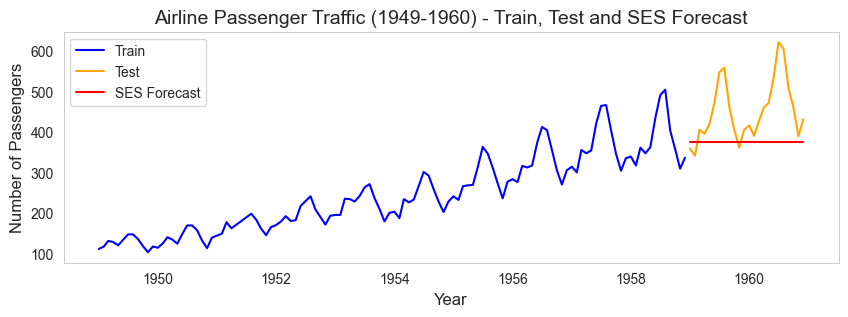

In [75]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_ses['ses_forecast'], label='SES Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and SES Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [76]:
# Calculate RMSE and MAPE

rmse = np.sqrt(
    mean_squared_error(test['Passengers'], y_hat_ses['ses_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_ses['ses_forecast']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Simple exponential smoothing forecast'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54
0,Simple exponential smoothing forecast,107.65,16.49


In [77]:
# Holt's method with trend

from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(np.asarray(train['Passengers']),
                             seasonal_periods=12, # seasonality is not being captured, but we need to specify seasonal_periods for the model to work, 12 - monthly data with yearly seasonality
                             trend='additive', # trend is being captured, additive trend, multiplicative trend is not being captured, so we specify trend as 'additive'
                            #  How to choose between additive and multiplicative trend in Holt's method?
                            # The choice between additive and multiplicative trend in Holt's method depends on the characteristics of the time series data. If the trend in the data is constant over time, an additive trend may be appropriate. However, if the trend is increasing or decreasing at a changing rate, a multiplicative trend may be more suitable. It is often recommended to visualize the data and analyze the trend before deciding which type of trend to use in Holt's method. Additionally, you can experiment with both types of trends and evaluate their performance using metrics such as RMSE or MAPE to determine which one provides better forecasts for your specific dataset.
                            seasonal=None) # seasonality is not being captured, so we specify seasonal as None
model_fit = model.fit(smoothing_level=0.2,
                      smoothing_slope=0.01,
                      optimized=False)
print(model_fit.params)
y_hat_holt = test.copy()
y_hat_holt['holt_forecast'] = model_fit.forecast(len(test)) # forecast for next 24 months (length of test set)
y_hat_holt

{'smoothing_level': 0.2, 'smoothing_trend': 0.01, 'smoothing_seasonal': None, 'damping_trend': nan, 'initial_level': np.float64(118.46666666666661), 'initial_trend': np.float64(2.060606060606071), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


,Passengers,holt_forecast
Month,,
1959-01-01,360.0,386.846420
1959-02-01,342.0,389.042292
1959-03-01,406.0,391.238164
1959-04-01,396.0,393.434035
1959-05-01,420.0,395.629907
1959-06-01,472.0,397.825778
1959-07-01,548.0,400.021650
1959-08-01,559.0,402.217521
1959-09-01,463.0,404.413393


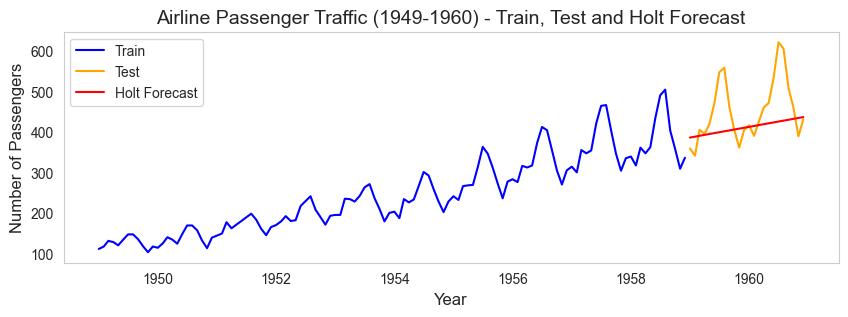

In [78]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_holt['holt_forecast'], label='Holt Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Holt Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [79]:
# Calculate RSME and MAPE

rmse = np.sqrt(
    mean_squared_error(test['Passengers'],
                       y_hat_holt['holt_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_holt['holt_forecast']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Holt\'s exponential smoothing method'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54
0,Simple exponential smoothing forecast,107.65,16.49
0,Holt's exponential smoothing method,80.91,11.39


In [80]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(np.asarray(train['Passengers']),
                             seasonal_periods=12,
                             trend='multiplicative', # trend is being captured, multiplicative trend, additive trend is not being captured, so we specify trend as 'multiplicative'
                             seasonal=None)
model_fit = model.fit(smoothing_level=0.3,
                      smoothing_slope=0.02,
                      optimized=False)
print(model_fit.params)
y_hat_holt = test.copy()
y_hat_holt['holt_forecast'] = model_fit.forecast(len(test))

{'smoothing_level': 0.3, 'smoothing_trend': 0.02, 'smoothing_seasonal': None, 'damping_trend': nan, 'initial_level': np.float64(118.46666666666661), 'initial_trend': np.float64(1.01739397349977), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


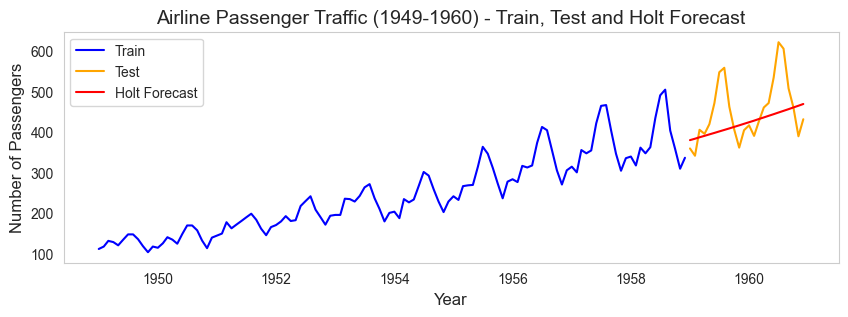

In [81]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_holt['holt_forecast'], label='Holt Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Holt Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [82]:
# Calculate RSME and MAPE

rmse = np.sqrt(
    mean_squared_error(test['Passengers'],
                       y_hat_holt['holt_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_holt['holt_forecast']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Holt\'s exponential smoothing method Multiplicative'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54
0,Simple exponential smoothing forecast,107.65,16.49
0,Holt's exponential smoothing method,80.91,11.39
0,Holt's exponential smoothing method Multiplica...,74.77,11.03


In [83]:
# Holt Winters' additive method with trend and seasonality

y_hat_hwa = test.copy()
model = ExponentialSmoothing(np.asarray(train['Passengers']),
                             seasonal_periods=12,
                             trend='add', # trend can be additive or multiplicative, we will use additive trend for this model
                             seasonal='add') # seasonality can be additive or multiplicative, we will use additive seasonality for this model
model_fit = model.fit(optimized=True) # optimized - whether to optimize the smoothing level, smoothing slope and smoothing seasonal parameters or not, if optimized is True, then the model will find the optimal values of these parameters that minimize the AIC (Akaike Information Criterion) of the model
print(model_fit.params)
y_hat_hwa['hw_forecast'] = model_fit.forecast(24)

{'smoothing_level': np.float64(0.23610560219665383), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.7638943978033461), 'damping_trend': nan, 'initial_level': np.float64(119.14074169720719), 'initial_trend': np.float64(2.2766875730059106), 'initial_seasons': array([ -9.41811972,  -3.89081873,   8.62457726,   3.53562444,
        -5.16151017,   8.98260655,  21.24828146,  19.33009884,
         5.24227504, -13.60667857, -28.28679349, -12.13724268]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


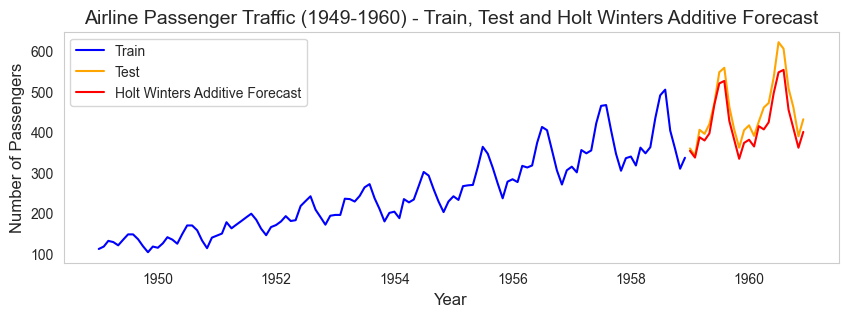

In [84]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_hwa['hw_forecast'], label='Holt Winters Additive Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Holt Winters Additive Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [85]:
# Calculate RMSE and MAPE

rmse = np.sqrt(mean_squared_error(test['Passengers'],
                                  y_hat_hwa['hw_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_hwa['hw_forecast']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Holt Winters\' additive method'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54
0,Simple exponential smoothing forecast,107.65,16.49
0,Holt's exponential smoothing method,80.91,11.39
0,Holt's exponential smoothing method Multiplica...,74.77,11.03
0,Holt Winters' additive method,35.87,6.72


In [86]:
# Holt Winter's multiplicative method with trend and seasonality

y_hat_hwm = test.copy()
model = ExponentialSmoothing(np.asarray(train['Passengers']),
                             seasonal_periods=12,
                             trend='add',
                             seasonal='mul')
model_fit = model.fit(optimized=True)
print(model_fit.params)
y_hat_hwm['hw_forecast'] = model_fit.forecast(24)

{'smoothing_level': np.float64(0.36559843774388573), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.6344015622561143), 'damping_trend': nan, 'initial_level': np.float64(124.65705541682726), 'initial_trend': np.float64(2.699837131299249), 'initial_seasons': array([0.87941901, 0.9250262 , 1.01675655, 0.96660283, 0.89217863,
       0.97565482, 1.06096748, 1.05376707, 0.96126551, 0.83767116,
       0.74471746, 0.85917776]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


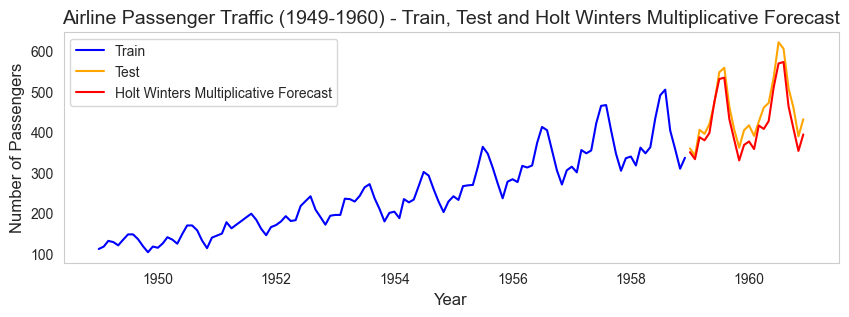

In [87]:
# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_hwm['hw_forecast'], label='Holt Winters Multiplicative Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Holt Winters Multiplicative Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [88]:
# Calculate RMSE and MAPE

rmse = np.sqrt(mean_squared_error(test['Passengers'],
                                  y_hat_hwm['hw_forecast'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_hwm['hw_forecast']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Holt Winters\' multiplicative method'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54
0,Simple exponential smoothing forecast,107.65,16.49
0,Holt's exponential smoothing method,80.91,11.39
0,Holt's exponential smoothing method Multiplica...,74.77,11.03
0,Holt Winters' additive method,35.87,6.72
0,Holt Winters' multiplicative method,32.45,6.45


The table compares the performance of different forecasting methods using two metrics: RMSE (Root Mean Squared Error) and MAPE (Mean Absolute Percentage Error). Here are the insights:

1. **Naive Method**:
   - RMSE: 137.51
   - MAPE: 23.63
   - Insight: This method, which uses the last observed value as the forecast, has relatively high error rates, indicating it's not very accurate.

2. **Simple Average Method**:
   - RMSE: 219.69
   - MAPE: 44.28
   - Insight: This method calculates the forecast by averaging all past observations. It has the highest error rates among the methods, showing it's the least effective.

3. **Simple Moving Average Forecast**:
   - RMSE: 103.33
   - MAPE: 15.54
   - Insight: This method averages a fixed number of the most recent observations. It's more accurate than the naive and simple average methods.

4. **Simple Exponential Smoothing Forecast**:
   - RMSE: 107.65
   - MAPE: 16.49
   - Insight: This method gives more weight to recent observations. It performs similarly to the simple moving average method but slightly less effective.

5. **Holt's Exponential Smoothing Method**:
   - RMSE: 80.91
   - MAPE: 11.39
   - Insight: This method accounts for both the trend and the level of the series, providing better accuracy than the previous methods.

6. **Holt's Exponential Smoothing Method (Multiplicative)**:
   - RMSE: 74.77
   - MAPE: 11.03
   - Insight: This method is similar to Holt's but assumes the trend is multiplicative. It performs slightly better than the additive version of Holt’s method.

7. **Holt-Winters' Additive Method**:
   - RMSE: 35.87
   - MAPE: 6.72
   - Insight: This method considers seasonality along with trend and level in an additive manner. It significantly improves accuracy, showing much lower error rates.

8. **Holt-Winters' Multiplicative Method**:
   - RMSE: 32.46
   - MAPE: 6.45
   - Insight: This method also accounts for seasonality, but in a multiplicative manner. It has the lowest error rates, indicating it is the most accurate method among those listed.

### Summary
- **Holt-Winters' Multiplicative Method** is the most accurate, with the lowest RMSE and MAPE.
- **Holt-Winters' Additive Method** also performs very well.
- **Holt's Exponential Smoothing** methods are more accurate than simple methods like the naive, simple average, and simple moving average forecasts.
- The **Simple Average Method** is the least effective with the highest error rates.

These insights suggest that methods considering trend and seasonality (especially in a multiplicative manner) provide more accurate forecasts.

{'smoothing_level': np.float64(0.3863511792609409), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.6136488207390591), 'damping_trend': nan, 'initial_level': np.float64(124.6723229053038), 'initial_trend': np.float64(1.009663784377982), 'initial_seasons': array([0.88975002, 0.93997249, 1.03786842, 0.98435384, 0.9026474 ,
       0.98838195, 1.07902394, 1.07263215, 0.97546684, 0.84534626,
       0.74877263, 0.87350129]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


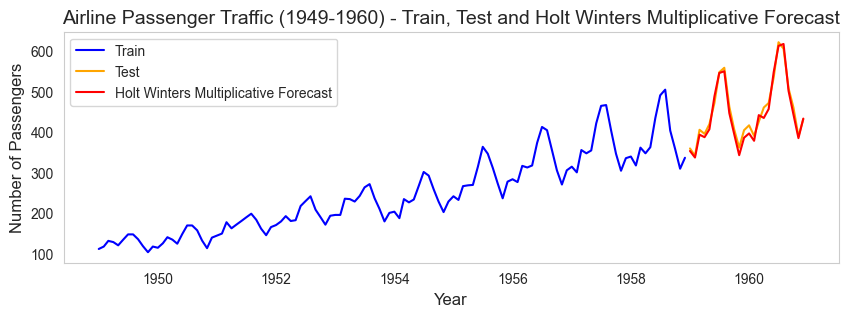

In [89]:
# Holt Winter's multiplicative method with trend and seasonality

y_hat_hwm = test.copy()
model = ExponentialSmoothing(np.asarray(train['Passengers']),
                             seasonal_periods=12,
                             trend='mul',
                             seasonal='mul')
model_fit = model.fit(optimized=True)
print(model_fit.params)
y_hat_hwm['hw_forecast_mul'] = model_fit.forecast(24)

# Plot train, test and forecast together

plt.figure(figsize=(10,3))
plt.plot(train.index, train['Passengers'], label='Train', color='blue')
plt.plot(test.index, test['Passengers'], label='Test', color='orange')
plt.plot(y_hat_hwm['hw_forecast_mul'], label='Holt Winters Multiplicative Forecast', color='red')
plt.title('Airline Passenger Traffic (1949-1960) - Train, Test and Holt Winters Multiplicative Forecast', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.grid()
plt.legend()
plt.show()

In [90]:
# Calculate RMSE and MAPE

rmse = np.sqrt(mean_squared_error(test['Passengers'],
                                  y_hat_hwm['hw_forecast_mul'])).round(2)
mape = np.round(
    np.mean(
        np.abs(test['Passengers'] - y_hat_hwm['hw_forecast_mul']) /
        test['Passengers']) * 100, 2)

tempResults = pd.DataFrame({
    'Method': ['Holt Winters\' multiplicative method_MUL'],
    'RMSE': [rmse],
    'MAPE': [mape]
})
results = pd.concat([results, tempResults])
results = results[['Method', 'RMSE', 'MAPE']]
results

,Method,RMSE,MAPE
0,Naive method,137.51,23.63
0,Simple average method,219.69,44.28
0,Simple moving average forecast,103.33,15.54
0,Simple exponential smoothing forecast,107.65,16.49
0,Holt's exponential smoothing method,80.91,11.39
0,Holt's exponential smoothing method Multiplica...,74.77,11.03
0,Holt Winters' additive method,35.87,6.72
0,Holt Winters' multiplicative method,32.45,6.45
0,Holt Winters' multiplicative method_MUL,13.36,2.71
